### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [6]:
data = pd.read_csv('data/coupons.csv')

In [7]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.
   ### Response
   The `pre-process.ipynb` file is used for analzing the data by looking at different charts, contents etc.

In [9]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


3. Decide what to do about your missing data -- drop, replace, other...
   ## Response
   Decided to drop the `car` and `toCoupon_GEQ5min` columns as `car` column does not have any data and `toCoupon_GEQ5min` column is always 1.
   Creating `clean_data` data after removing these two columns.

In [11]:
data_withoutcar = data.drop('car',axis=1)
clean_data = data_withoutcar.drop('toCoupon_GEQ5min',axis=1)
clean_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,1,1,0,1,0


4. What proportion of the total observations chose to accept the coupon?
   ## Response
   A Pie chart on column `Y` shows the `56.8%` has accepted the coupon and `43.2%` has not accepted the coupon.


<Axes: ylabel='count'>

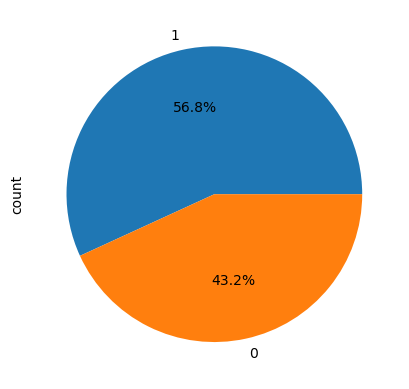

In [13]:
clean_data['Y'].value_counts().plot(kind='pie',autopct='%1.1f%%') 

5. Use a bar plot to visualize the `coupon` column.
   ## Response
   A Bar chart on column `coupon` shows the different type of coupons and their occurrence.

<Axes: xlabel='coupon'>

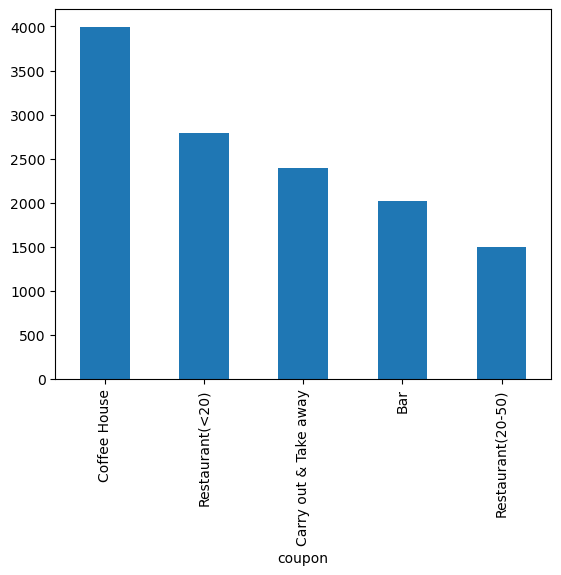

In [15]:
clean_data['coupon'].value_counts().plot(kind='bar')

6. Use a histogram to visualize the temperature column.
   ### Response
   A histogram on column `temperature` shows temperature buckets and their counts.

<Axes: ylabel='Frequency'>

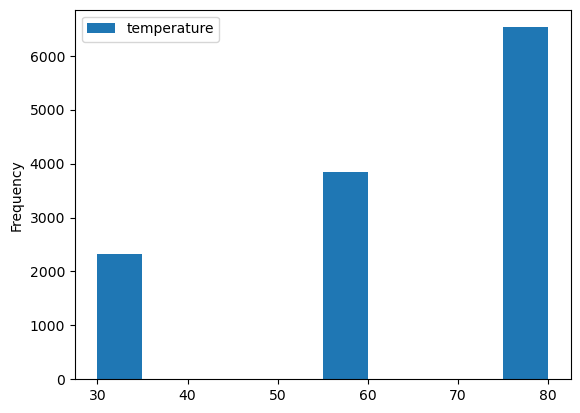

In [17]:
clean_data.plot(kind='hist',y='temperature')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.
   ## Response
   Creating a new data frame `data_bar_coupon` where coupon value is set to `"Bar"`

In [19]:
data_bar_coupon = clean_data.query('coupon == "Bar"')
data_bar_coupon                             

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,NaN,4~8,1~3,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,never,1~3,4~8,1~3,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,never,1~3,4~8,1~3,1,0,0,1,0


2. What proportion of bar coupons were accepted?
   ## Response
   A Pie chart shows the the acceptance rate is `41%` and rejection rate is `59%`.
   For further analysis, selecting only accepted coupon. Instead of all columns reducing the columns as well.
   A new data frame named `data_accepted` is created for further analysis.
   Finally a Pie chart is created on the new data frame that shows the breakdown of Bar attendances.

   **Proportion**
   - Accpetance Rate - `41%`
   - Rejection Rate - `59%`

<Axes: ylabel='count'>

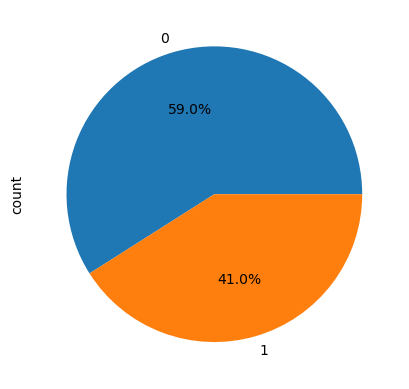

In [21]:
data_bar_coupon['Y'].value_counts().plot(kind='pie', autopct='%1.1f%%') 

<Axes: ylabel='count'>

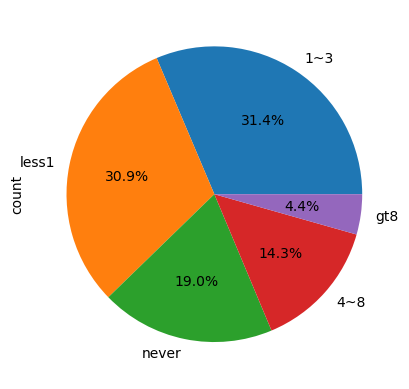

In [22]:
data_accepted = data_bar_coupon.query('Y == 1')
data_accepted = data_accepted[['passanger','occupation','gender','age','income','RestaurantLessThan20','Bar','maritalStatus']]
data_accepted['Bar'].value_counts().plot(kind='pie', autopct='%1.1f%%')

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.
   ## Response
   `bar_3_or_less` gives the number of person who went the bar 3 times or less and `rate_3_and_less` provides the percentage of the that. Similarly  `bar_more_than_3` gives the number of person who went the bar more than 3 times `rate_more_than_3` provides the percentage of the that.

   **Conclusion**

   `Who went to the Bar 3 times or less has higher acceptance rate`.

In [24]:
bar_3_or_less = data_accepted.query('Bar == "1~3" or Bar == "less1" or Bar == "never"')
rate_3_and_less = bar_3_or_less.shape[0]/data_accepted.shape[0]*100
bar_more_than_3 = data_accepted.query('Bar == "gt8" or Bar == "4~8"')
rate_more_than_3 = bar_more_than_3.shape[0]/data_accepted.shape[0]*100
print (round(rate_3_and_less,2), round(rate_more_than_3,2))
if (rate_3_and_less > rate_more_than_3) :
    print ("Who went to the Bar 3 or less has higher acceptance rate")
else :
    print ("Who went to the Bar more than 3 has higher acceptance rate")

80.53 18.5
Who went to the Bar 3 or less has higher acceptance rate


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?
   ## Response
   `data_more_than_25` gives the number of person who went the bar more than once and age more than 25 and `rate_more_than_25` provides the percentage of the that. Similarly  `data_less_than_25` gives the number of person who went the bar once and age less than 25 `rate_less_than_25` provides the percentage of the that.

   **Conclusion**
   
   `Those who went to the Bar once 25 years of age and more has higher acceptance rate`

In [26]:
more_than_25 = ['26','31','50plus','41','36','46']
less_than_25 = ['below21','21']
data_more_than_once = data_accepted.query('Bar == "1~3" or Bar == "gt8" or Bar == "4~8"')

data_more_than_25 = data_more_than_once.query('age in @more_than_25')
data_less_than_25 = data_more_than_once.query('age in @less_than_25')
rate_more_than_25 = data_more_than_25.shape[0]/data_more_than_once.shape[0]*100
rate_less_than_25 = data_less_than_25.shape[0]/data_more_than_once.shape[0]*100

print (round(rate_more_than_25,2), round(rate_less_than_25,2))
if (rate_more_than_25 > rate_less_than_25) :
    print ("Who are 25 years or more has higher acceptance rate")
else :
    print ("Who are less than 25 years has higher acceptance rate")

71.22 28.78
Who are 25 years or more has higher acceptance rate


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.
   ## Response
   `data_other_than_kid` gives the number of person who went the bar more than once and no child was in the passenger and `rate_other_than_kid` provides the percentage of the that. Similarly  `data_kid` gives the number of person who went the bar once and child is in the passenger `rate_kid` provides the percentage of the that.

   **Conclusion**
   
   `Those who went to the Bar once Who had passengers other than kid has higher acceptance rate`

In [28]:
other_than_kid = ['Alone','Friend(s)','Partner']
data_other_than_kid = data_more_than_once.query('passanger in @other_than_kid')
rate_other_than_kid = data_other_than_kid.shape[0]/data_more_than_once.shape[0]*100

data_kid = data_more_than_once.query('passanger =="Kid(s)"')
rate_kid = data_kid.shape[0]/data_more_than_once.shape[0]*100

print (round(rate_other_than_kid,2), round(rate_kid,2))
if (rate_other_than_kid > rate_kid) :
    print ("Who had passengers other than kid has higher acceptance rate")
else :
    print ("Who had passengers with kid has higher acceptance rate")

95.85 4.15
Who had passengers other than kid has higher acceptance rate


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.

## Response
   Calculated all 3 percentages below
    `rate_other_than_kid_widowed` - go to bars more than once a month, had passengers that were not a kid, and were not widowed
    `rate_less_than_30` - go to bars more than once a month and are under the age of 30
    `rate_cheap` - go to cheap restaurants more than 4 times a month and income is less than 50K.
    
**Conclusion**

It shows first type has higher acceptance rate, then the 2nd category and finally 3rd category.

In [30]:
less_than_30 = ['below21','21','26']
cheap = ['4~8','gt8']
less_50k = ['$25000 - $37499','$37500 - $49999','$12500 - $24999','Less than $12500']
maritalStatus = ['Married partner','Single','Unmarried partner','Divorced']

data_other_than_kid_widowed = data_other_than_kid.query('maritalStatus in @maritalStatus')
rate_other_than_kid_widowed = data_other_than_kid_widowed.shape[0]/data_accepted.shape[0]*100

data_less_than_30 = data_more_than_once.query('age in @less_than_30')
rate_less_than_30 = data_less_than_30.shape[0]/data_accepted.shape[0]*100

data_cheap = data_accepted.query('income in @less_50k and RestaurantLessThan20 in @cheap')
rate_cheap = data_cheap.shape[0]/data_accepted.shape[0]*100

print (round(rate_other_than_kid_widowed,2), round(rate_less_than_30,2) , round(rate_cheap,2))

47.52 30.11 18.86


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?
   ## Response
   Here is list of potential candiates who are most likely to accept the coupon.
   - Who went to the Bar 3 or less has higher acceptance rate. Rate is almost `80%`.
   - Who are went to Bar once and 25 years or more has higher acceptance rate. Rate is almost `70%`.
   - Who went to the Bar once and had passengers other than kid has higher acceptance rate. Rate is almost `96%`. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  
## Response
I have looked into `gender` and `martialStatus` columns for further analysis and decided for dig more `maritalStatus`. The bar chart below shows the data distribution of the `martialStatus`. Looking at the bar I have decided to dig more on the `Single` person. Created a new data frame named `data_single_marital` from `clean_data`.


<Axes: xlabel='maritalStatus'>

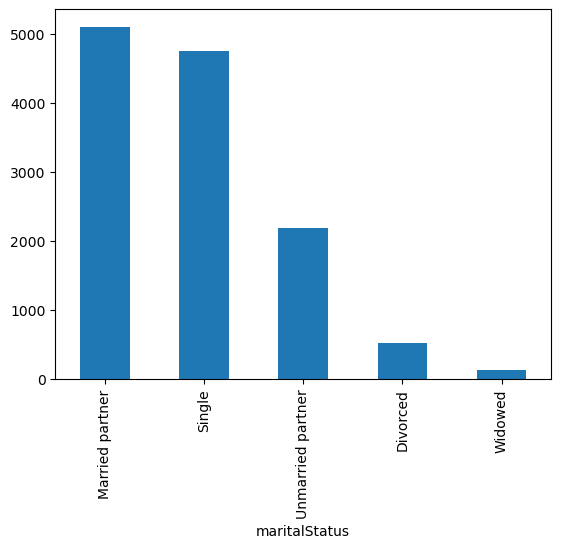

In [33]:
clean_data['maritalStatus'].value_counts().plot(kind='bar')

In [34]:
data_single_marital = clean_data.query('maritalStatus == "Single"')
data_single_marital

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,0,1,1
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,0,1,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,never,less1,4~8,4~8,less1,1,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,never,1~3,4~8,1~3,1,1,0,1,0


### Single Person Accept vs Reject
A pie chart displays signle person who accepted and rejected the coupon.

<Axes: ylabel='count'>

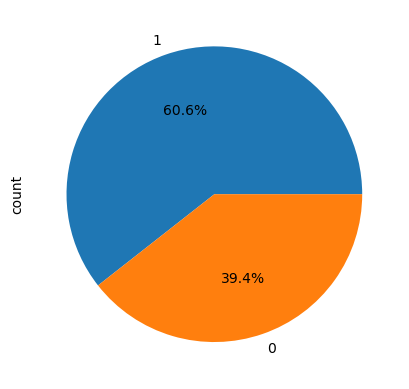

In [36]:
data_single_marital['Y'].value_counts().plot(kind='pie', autopct='%1.1f%%') 

### Analyze Single Person Who Accepted Coupon
Focusing on the single person who accepted the coupon. Reducing the columns. Further analysing those who are interested in `CarryAway`.
The pie chart displays `CarryAway` counts.

<Axes: ylabel='count'>

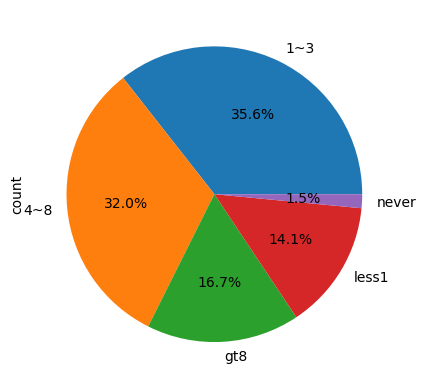

In [38]:
data_single_marital_accepted = data_single_marital.query('Y == 1')
data_single_marital_accepted = data_single_marital_accepted[['passanger','occupation','gender','age','income','CarryAway','Bar','maritalStatus']]
data_single_marital_accepted['CarryAway'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [39]:
data_single_marital_accepted

,passanger,occupation,gender,age,income,CarryAway,Bar,maritalStatus
22,Alone,Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
24,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
29,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
31,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
33,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
...,...,...,...,...,...,...,...,...
12671,Partner,Sales & Related,Male,26,$75000 - $87499,1~3,never,Single
12676,Alone,Sales & Related,Male,26,$75000 - $87499,1~3,never,Single
12677,Partner,Sales & Related,Male,26,$75000 - $87499,1~3,never,Single
12679,Partner,Sales & Related,Male,26,$75000 - $87499,1~3,never,Single


## Compare Male vs Female - Who took CarryAway 4 or more
The comparison shows male has higher rate of acceptance. Almost 10% higher in the category of 4 or more CarryAway.

In [41]:
data_female = data_single_marital_accepted.query('(gender == "Female") and (CarryAway == "4~8" or CarryAway == "gt8")')
data_female

,passanger,occupation,gender,age,income,CarryAway,Bar,maritalStatus
176,Alone,Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
177,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
179,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
180,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
181,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
...,...,...,...,...,...,...,...,...
11727,Alone,Arts Design Entertainment Sports & Media,Female,21,$75000 - $87499,gt8,gt8,Single
11730,Alone,Arts Design Entertainment Sports & Media,Female,21,$75000 - $87499,gt8,gt8,Single
11732,Alone,Arts Design Entertainment Sports & Media,Female,21,$75000 - $87499,gt8,gt8,Single
11733,Alone,Arts Design Entertainment Sports & Media,Female,21,$75000 - $87499,gt8,gt8,Single


In [42]:
data_male = data_single_marital_accepted.query('(gender == "Male") and (CarryAway == "4~8" or CarryAway == "gt8")')
data_male

,passanger,occupation,gender,age,income,CarryAway,Bar,maritalStatus
22,Alone,Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
24,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
29,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
31,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
33,Friend(s),Architecture & Engineering,Male,21,$62500 - $74999,4~8,never,Single
...,...,...,...,...,...,...,...,...
12384,Alone,Unemployed,Male,26,$12500 - $24999,4~8,1~3,Single
12387,Alone,Unemployed,Male,26,$12500 - $24999,4~8,1~3,Single
12388,Alone,Unemployed,Male,26,$12500 - $24999,4~8,1~3,Single
12389,Alone,Unemployed,Male,26,$12500 - $24999,4~8,1~3,Single


In [43]:
print (round(data_female.shape[0]*100/data_single_marital_accepted.shape[0],2), round(data_male.shape[0]*100/data_single_marital_accepted.shape[0],2))

19.21 28.86


## Compare Male vs Female - Income less than 50K
The comparison shows male has higher rate of acceptance. But the difference is not that significant in this catefory.

In [45]:
data_female_income = data_single_marital_accepted.query('gender == "Female" and income in @less_50k')
data_female_income

,passanger,occupation,gender,age,income,CarryAway,Bar,maritalStatus
176,Alone,Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
177,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
179,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
180,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
181,Friend(s),Healthcare Practitioners & Technical,Female,26,$25000 - $37499,4~8,never,Single
...,...,...,...,...,...,...,...,...
12362,Alone,Education&Training&Library,Female,31,$25000 - $37499,less1,less1,Single
12363,Alone,Education&Training&Library,Female,31,$25000 - $37499,less1,less1,Single
12365,Alone,Education&Training&Library,Female,31,$25000 - $37499,less1,less1,Single
12366,Alone,Education&Training&Library,Female,31,$25000 - $37499,less1,less1,Single


In [46]:
data_male_income = data_single_marital_accepted.query('gender == "Male" and income in @less_50k')
data_male_income

,passanger,occupation,gender,age,income,CarryAway,Bar,maritalStatus
44,Alone,Student,Male,46,$12500 - $24999,1~3,never,Single
45,Friend(s),Student,Male,46,$12500 - $24999,1~3,never,Single
47,Friend(s),Student,Male,46,$12500 - $24999,1~3,never,Single
48,Friend(s),Student,Male,46,$12500 - $24999,1~3,never,Single
49,Friend(s),Student,Male,46,$12500 - $24999,1~3,never,Single
...,...,...,...,...,...,...,...,...
12577,Alone,Student,Male,21,$12500 - $24999,1~3,never,Single
12578,Alone,Student,Male,21,$12500 - $24999,1~3,never,Single
12579,Alone,Student,Male,21,$12500 - $24999,1~3,never,Single
12581,Alone,Student,Male,21,$12500 - $24999,1~3,never,Single


In [47]:
print (round(data_female_income.shape[0]*100/data_single_marital_accepted.shape[0],2), round(data_male_income.shape[0]*100/data_single_marital_accepted.shape[0],2))

31.96 34.77


## Male and Female Histogram based on Age
- Male wins in `below21`, `21`, `26`, `36`, `46`
- Female wins in `31`, `41` and `50plus`


<Axes: xlabel='age', ylabel='Count'>

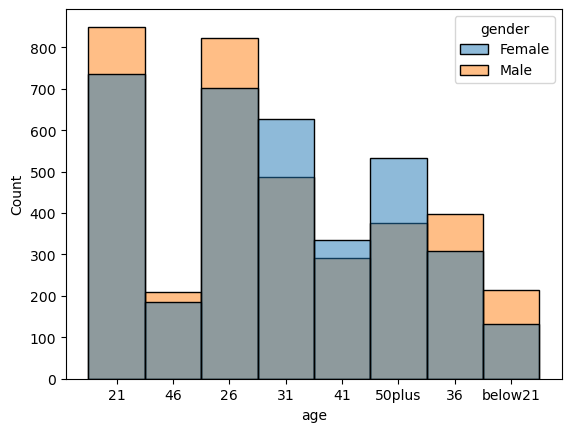

In [49]:
sns.histplot(data = clean_data.query('Y == 1'), x = 'age', hue = 'gender')

## Male and Female Histogram with KDE of visiting Bar number of times
- Male wins in `1~3`, `4~8` and `gt8`
- Female wins in `never` and `less1`

<Axes: xlabel='Bar', ylabel='Count'>

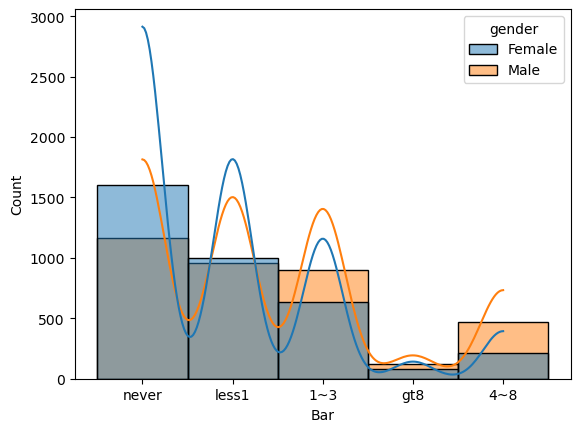

In [51]:
sns.histplot(data = clean_data.query('Y == 1'), x = 'Bar', kde=True, hue = 'gender')

## Marital Status Histogram with KDE of CarryAway number of times
- Married partner wins in `1~3`, `14~8`
- Single wins in `less1` and `gt8`

<Axes: xlabel='CarryAway', ylabel='Count'>

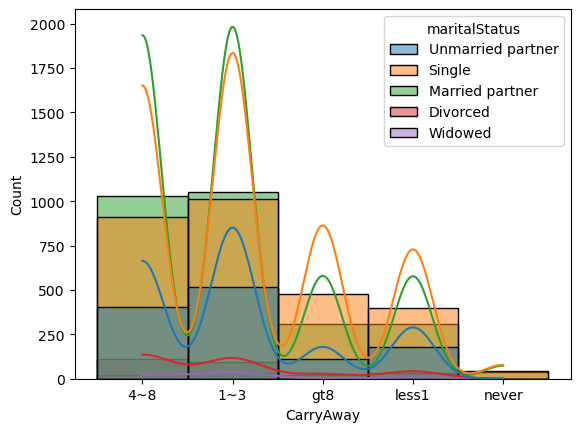

In [53]:
sns.histplot(data = clean_data.query('Y == 1'), x = 'CarryAway', kde=True, hue = 'maritalStatus')